# Data Quality Assessment & Preprocessing

This notebook performs data cleaning and preprocessing including:
- Handling missing values
- Detecting and removing outliers
- Normalizing data
- Applying PCA

# 1.Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# 2.Load Dataset

In [7]:
df = pd.read_csv("data.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0


# 4.Data Quality Check

In [8]:
# Check missing values
df.isnull().sum()

# Check for '?' values
(df == '?').sum()

# Check duplicates
df.duplicated().sum()

np.int64(1)

# 5.Replace '?' with NaN

In [11]:
df.replace('?', np.nan, inplace=True)

# 6.Convert Data Types

In [12]:
cols = ['trestbps','chol','fbs','restecg','thalach','exang','slope','ca','thal']

for col in cols:
    df[col] = pd.to_numeric(df[col])

# 7.Handle Missing Value

In [13]:
df.fillna(df.mean(), inplace=True)

df.isnull().sum()

age           0
sex           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
num           0
dtype: int64

# Outlier Detection using IQR

# 8.IQR

In [15]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[~((df < lower) | (df > upper)).any(axis=1)]

df.shape

(170, 14)

# 9.Min-Max Scaling

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_minmax = scaler.fit_transform(df)

df_minmax = pd.DataFrame(df_minmax, columns=df.columns)
df_minmax.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,0.000000,1.0,0.333333,0.358974,0.522822,0.0,0.0,0.70,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,1.0,0.333333,0.615385,0.555389,0.0,0.0,0.80,0.0,0.0,0.0,0.0,0.0,0.0
2,0.081081,0.0,0.333333,0.166667,0.336100,0.0,0.0,0.75,0.0,0.0,0.0,0.0,0.0,0.0
3,0.081081,1.0,0.333333,0.230769,0.448133,0.0,0.0,0.94,0.0,0.0,0.0,0.0,0.0,0.0
4,0.081081,1.0,0.333333,0.423077,0.568465,0.0,0.0,0.65,0.0,0.0,0.0,0.0,0.0,0.0


# 10.Z-score Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_zscore = scaler.fit_transform(df)

df_zscore = pd.DataFrame(df_zscore, columns=df.columns)
df_zscore.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,-2.372032,0.581879,-0.981762,-0.688121,0.060845,0.0,0.0,0.836075,-0.563764,-0.57443,-0.609071,0.0,-1.776357e-15,-0.663836
1,-2.372032,0.581879,-0.981762,0.627746,0.234736,0.0,0.0,1.270599,-0.563764,-0.57443,-0.609071,0.0,-1.776357e-15,-0.663836
2,-1.977981,-1.718572,-0.981762,-1.675020,-0.936141,0.0,0.0,1.053337,-0.563764,-0.57443,-0.609071,0.0,-1.776357e-15,-0.663836
3,-1.977981,0.581879,-0.981762,-1.346054,-0.337949,0.0,0.0,1.878933,-0.563764,-0.57443,-0.609071,0.0,-1.776357e-15,-0.663836
4,-1.977981,0.581879,-0.981762,-0.359154,0.304553,0.0,0.0,0.618813,-0.563764,-0.57443,-0.609071,0.0,-1.776357e-15,-0.663836


# 11.Correlation

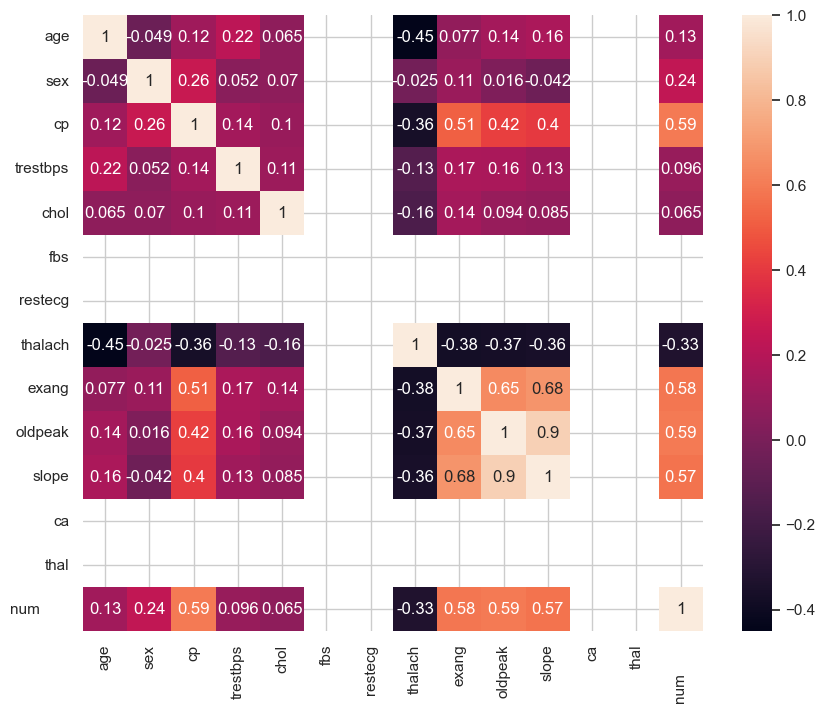

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

# 12.PCA

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df)

df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca.head()

,PC1,PC2
0,-0.112730,23.339870
1,7.505993,31.345457
2,-45.967346,24.518764
3,-20.978578,45.396802
4,11.623354,18.597747


# 13.PCA Plot

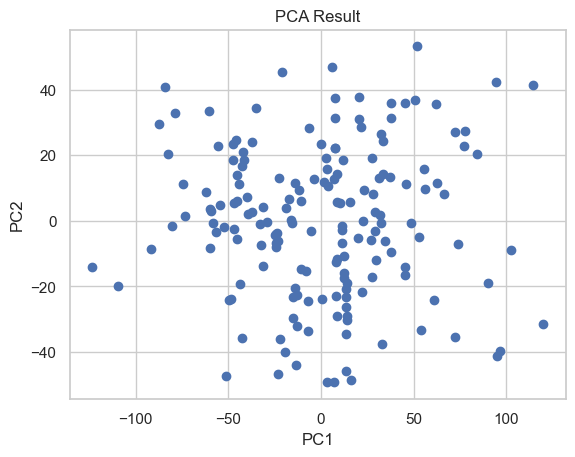

In [22]:
plt.scatter(df_pca['PC1'], df_pca['PC2'])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Result")
plt.show()